# MCDI504 — Machine Learning I
# Avance del Proyecto — Fase 2: Búsqueda y Recopilación de Información
## Implementación de Modelos de Regresión Supervisada
### Notebook F2_Regresion.ipynb

**Curso:** MCDI504 - Machine Learning I
**Grupo:** 5

**Integrantes:**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Fecha de entrega:** Semana 2 (fecha exacta según calendario académico del curso; completar en el informe)

---

**Índice**
1. [Contexto y objetivo de la Fase 2](#1)
2. [Librerías necesarias](#2)
3. [Carga del conjunto de datos](#3)
4. [Descripción del conjunto de datos y preprocesamiento](#4)
5. [Modelo de regresión lineal multivariable](#5)
6. [Modelo de árbol de decisión para regresión](#6)
7. [Modelo de red neuronal (MLP) para regresión](#7)
8. [Evaluación de modelos de regresión](#8)
9. [Comparación de modelos](#9)
10. [Conclusiones](#10)
11. [Referencias](#11)


<a id="1"></a>
## 1. Contexto y objetivo de la Fase 2

En la **Fase 1** de este proyecto, **NextWork Advisory** definió el problema de negocio de estimar el riesgo de automatización de cargos hacia 2030 a partir del dataset **AI Impact on Jobs 2030**, y justificó un enfoque de **clasificación supervisada multiclase** sobre la variable ordinal `Risk_Category` (Low/Medium/High). Esa misma fase identificó que el dataset también contiene `Automation_Probability_2030`, la probabilidad continua (entre 0 y 1) de la cual se deriva por corte `Risk_Category`, y dejó planteada como línea de análisis complementaria la posibilidad de abordar el problema como **regresión supervisada** sobre esta variable continua.

La **Fase 2** del proyecto ABP (RA2) exige precisamente implementar y comparar modelos de regresión supervisada. En consecuencia, en este notebook se retoma el mismo dataset de la Fase 1 y se define como **variable objetivo (target) `Automation_Probability_2030`**, con el fin de:

- Preparar analíticamente el conjunto de datos para el modelamiento de regresión (selección de variables, tratamiento de valores faltantes, partición entrenamiento/prueba y escalado).
- Implementar y entrenar tres modelos de regresión supervisada: **regresión lineal multivariable**, **árbol de decisión para regresión** y **red neuronal (MLP) para regresión**.
- Evaluar el desempeño de cada modelo mediante las métricas **MSE**, **RMSE** y **R²** sobre el conjunto de prueba.
- Comparar los modelos y determinar cuál ofrece el mejor desempeño predictivo, generando evidencia útil para la toma de decisiones de NextWork Advisory y para la continuidad del proyecto en fases posteriores (F3-F4).

**Relación entre problema, datos y variable continua a predecir:** estimar directamente `Automation_Probability_2030` permite a NextWork Advisory disponer de un indicador numérico continuo y granular del riesgo de automatización de un cargo (en lugar de solo una categoría discreta), lo que resulta útil para priorizar de forma más fina las inversiones en recapacitación (*reskilling*) entre cargos que, aunque pertenezcan a la misma categoría de riesgo, presenten probabilidades de automatización distintas.


<a id="2"></a>
## 2. Librerías necesarias

Importamos las librerías para manipulación de datos, visualización, preprocesamiento, los tres modelos de regresión a implementar (lineal, árbol de decisión y red neuronal) y las métricas de evaluación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Paleta categórica fija (orden fijo por modelo, consistente en todo el notebook)
COLOR_LINEAL = "#2a78d6"   # azul
COLOR_ARBOL  = "#eb6834"   # naranjo
COLOR_MLP    = "#1baf7a"   # aqua

sns.set_style("whitegrid")
RANDOM_STATE = 42

<a id="3"></a>
## 3. Carga del conjunto de datos

Se reutiliza el mismo dataset **AI Impact on Jobs 2030** de la Fase 1, disponible en el repositorio del proyecto (`../data/AI_Impact_on_Jobs_2030.csv`), asegurando coherencia entre ambas fases.

In [2]:
df = pd.read_csv("../data/AI_Impact_on_Jobs_2030.csv")

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (3000, 18)


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


<a id="4"></a>
## 4. Descripción del conjunto de datos y preprocesamiento

### 4.1 Descripción general del dataset

El dataset contiene **3.000 observaciones** (perfiles laborales) y **18 columnas**: el cargo (`Job_Title`, 20 categorías), variables numéricas de perfil (`Average_Salary`, `Years_Experience`), el nivel educativo (`Education_Level`, ordinal), dos índices de contexto (`AI_Exposure_Index`, `Tech_Growth_Factor`), diez puntajes de habilidades (`Skill_1`–`Skill_10`, escala 0-1) y dos variables de resultado: `Automation_Probability_2030` (continua, 0-1) y `Risk_Category` (categórica, derivada de la anterior por corte).

### 4.2 Variable objetivo y variables predictoras

- **Variable objetivo (target):** `Automation_Probability_2030` — variable numérica continua, en el rango [0, 1], que representa la probabilidad estimada de automatización del cargo hacia 2030.
- **Variables predictoras candidatas:** `Average_Salary`, `Years_Experience`, `Education_Level`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10` y `Job_Title`.

### 4.3 Tratamiento de valores faltantes

Se verifica la presencia de valores nulos en el dataset completo.

In [3]:
print("Valores nulos por columna:")
display(df.isnull().sum())
print(f"\nTotal de valores nulos en el dataset: {df.isnull().sum().sum()}")

Valores nulos por columna:


Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64


Total de valores nulos en el dataset: 0


Al igual que en la Fase 1, el dataset **no presenta valores faltantes** en ninguna de sus 18 columnas (0 nulos sobre 3.000 observaciones x 18 variables). Por tratarse de un dataset simulado y completo, **no se requiere imputación ni eliminación de registros**; el tratamiento de valores faltantes se limita a la verificación documentada anterior.

### 4.4 Exploración adicional: relación entre `Job_Title` y la variable objetivo

En una primera iteración de esta fase, `Job_Title` se excluyó del conjunto de predictores por ser una variable nominal de 20 categorías (ver justificación original en la sección 4.5). Sin embargo, dado que los 15 predictores numéricos/ordinales restantes mostraron una relación muy débil con `Automation_Probability_2030` (Fase 1), se explora explícitamente si el propio `Job_Title` concentra señal predictiva relevante, calculando el promedio de la variable objetivo por cargo.

In [4]:
medias_por_cargo = (
    df.groupby("Job_Title")["Automation_Probability_2030"]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
)
display(medias_por_cargo)

media_global = df["Automation_Probability_2030"].mean()
medias_por_fila = df.groupby("Job_Title")["Automation_Probability_2030"].transform("mean")
ss_entre_grupos = ((medias_por_fila - media_global) ** 2).sum()
ss_total = ((df["Automation_Probability_2030"] - media_global) ** 2).sum()
r2_agrupacion = ss_entre_grupos / ss_total

print(f"\nProporción de varianza explicada solo por el promedio de cada Job_Title: {r2_agrupacion:.4f}")

,mean,std,count
Job_Title,,,
AI Engineer,0.172214,0.073925,140
Research Scientist,0.174161,0.068380,149
Nurse,0.175634,0.076385,142
Teacher,0.175783,0.070179,166
Doctor,0.176742,0.071862,132
Financial Analyst,0.485099,0.110646,151
Mechanic,0.485294,0.108457,136
Lawyer,0.486439,0.113070,132
HR Specialist,0.490764,0.112213,157



Proporción de varianza explicada solo por el promedio de cada Job_Title: 0.8570


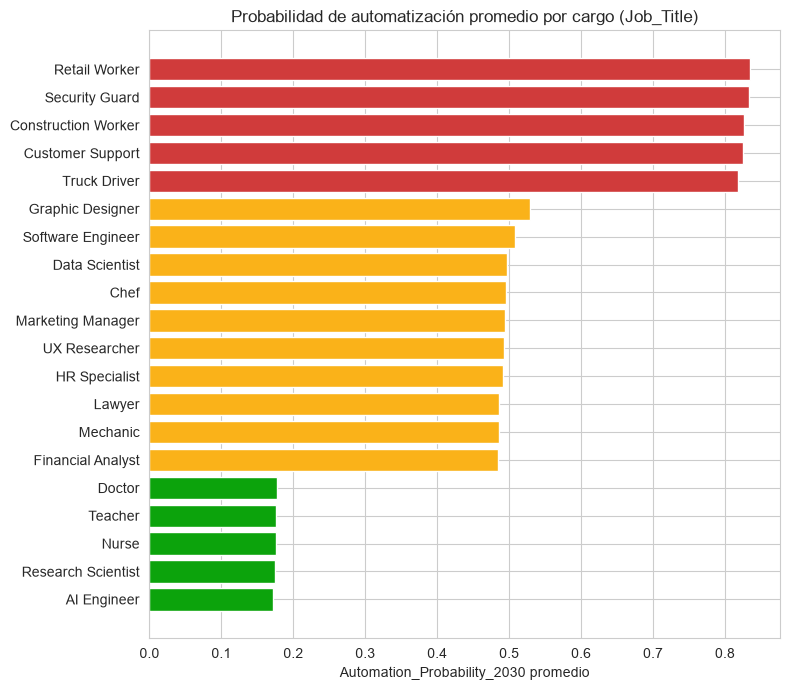

In [5]:
def color_por_riesgo(v):
    if v < 0.30:
        return "#0ca30c"   # riesgo bajo
    elif v < 0.70:
        return "#fab219"   # riesgo medio
    return "#d03b3b"       # riesgo alto

medias_ordenadas = df.groupby("Job_Title")["Automation_Probability_2030"].mean().sort_values()
colores_barras = [color_por_riesgo(v) for v in medias_ordenadas]

plt.figure(figsize=(8, 7))
plt.barh(medias_ordenadas.index, medias_ordenadas.values, color=colores_barras)
plt.xlabel("Automation_Probability_2030 promedio")
plt.title("Probabilidad de automatización promedio por cargo (Job_Title)")
plt.tight_layout()
plt.savefig("../figures/f2_job_title_means.png", dpi=150, bbox_inches="tight")
plt.show()

El promedio de `Automation_Probability_2030` por cargo se agrupa en **tres niveles muy nítidos**: un grupo de riesgo bajo (≈0,17-0,18: AI Engineer, Research Scientist, Nurse, Teacher, Doctor), un grupo de riesgo medio (≈0,48-0,53: Financial Analyst, Mechanic, Lawyer, HR Specialist, UX Researcher, Marketing Manager, Chef, Data Scientist, Software Engineer, Graphic Designer) y un grupo de riesgo alto (≈0,82-0,83: Truck Driver, Customer Support, Construction Worker, Security Guard, Retail Worker).

Solo la media por `Job_Title` explica **cerca del 86% de la varianza** de `Automation_Probability_2030` (`r2_agrupacion` ≈ 0,857) — muy por encima de lo obtenido con el conjunto de 15 variables numéricas/ordinales analizado en la Fase 1, cuya correlación de Pearson con la variable objetivo era cercana a cero. Esta evidencia cuantitativa **revierte la decisión de preprocesamiento inicial**: en la sección 4.5, `Job_Title` se incorpora como predictor.

### 4.5 Selección y codificación de variables

A la luz de la exploración anterior, se toman las siguientes decisiones técnicas para construir la matriz de predictores `X`:

- **Se codifica `Education_Level`** de forma ordinal (`High School`=1 < `Bachelor's`=2 < `Master's`=3 < `PhD`=4), replicando el criterio ya utilizado en la Fase 1, ya que es una variable categórica con orden natural.
- **Se incorpora `Job_Title` mediante codificación *one-hot*** (`pd.get_dummies`, con `drop_first=True` para evitar la trampa de la variable dummy), generando 19 columnas binarias sobre las 20 categorías del cargo. La sección 4.4 mostró que esta variable, por sí sola, explica ~86% de la varianza de `Automation_Probability_2030`; excluirla —como se hizo en una primera iteración de esta fase, priorizando parsimonia sobre poder predictivo— descartaba la señal más relevante disponible en el dataset.
- **Se excluyen `Risk_Category` y su codificación ordinal** del conjunto de predictores, porque ambas se derivan **directamente** de `Automation_Probability_2030` (la propia variable objetivo) mediante un corte por umbrales (Low: 0.05–0.30, Medium: 0.31–0.70, High: 0.71–0.95). Incluirlas constituiría una **fuga de información (data leakage)**.

En consecuencia, el conjunto final de **34 variables predictoras** queda compuesto por las 15 variables numéricas/ordinales ya utilizadas (`Average_Salary`, `Years_Experience`, `Education_Level_Num`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10`) más las **19 columnas dummy de `Job_Title`**.

In [6]:
orden_educacion = {"High School": 1, "Bachelor's": 2, "Master's": 3, "PhD": 4}
df["Education_Level_Num"] = df["Education_Level"].map(orden_educacion)

variables_numericas = (
    ["Average_Salary", "Years_Experience", "Education_Level_Num",
     "AI_Exposure_Index", "Tech_Growth_Factor"]
    + [f"Skill_{i}" for i in range(1, 11)]
)

job_title_dummies = pd.get_dummies(df["Job_Title"], prefix="Job_Title", drop_first=True).astype(int)

X = pd.concat([df[variables_numericas], job_title_dummies], axis=1)
y = df["Automation_Probability_2030"]

categoria_referencia = sorted(df["Job_Title"].unique())[0]
print(f"Variables numéricas/ordinales: {len(variables_numericas)}")
print(f"Columnas dummy de Job_Title: {job_title_dummies.shape[1]} (categoría de referencia: '{categoria_referencia}')")
print(f"\nDimensiones de X (predictoras): {X.shape}")
print(f"Dimensiones de y (variable objetivo): {y.shape}")

Variables numéricas/ordinales: 15
Columnas dummy de Job_Title: 19 (categoría de referencia: 'AI Engineer')

Dimensiones de X (predictoras): (3000, 34)
Dimensiones de y (variable objetivo): (3000,)


### 4.6 Partición en entrenamiento y prueba

Se divide el dataset en un 80% para entrenamiento y un 20% para prueba, usando `random_state=42` para asegurar la reproducibilidad de los resultados en los tres modelos que se implementarán a continuación.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test:  {y_test.shape}")

Dimensiones de X_train: (2400, 34)
Dimensiones de X_test:  (600, 34)
Dimensiones de y_train: (2400,)
Dimensiones de y_test:  (600,)


### 4.7 Escalado de variables

Las variables predictoras presentan escalas muy distintas (`Average_Salary` en decenas de miles de dólares versus índices, habilidades y dummies de `Job_Title` entre 0 y 1), tal como se identificó en la Fase 1. Se estandarizan con `StandardScaler` (media 0, desviación estándar 1), ajustado **únicamente con los datos de entrenamiento** para evitar fuga de información desde el conjunto de prueba. El escalado es especialmente relevante para la regresión lineal y, sobre todo, para la red neuronal (MLP), que es sensible a la escala de los datos; se aplica de forma consistente a los tres modelos para mantener un único pipeline de preprocesamiento comparable.

In [8]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Primeras filas de X_train escalado:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Primeras filas de X_train escalado:


,Average_Salary,Years_Experience,Education_Level_Num,AI_Exposure_Index,Tech_Growth_Factor,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,...,Job_Title_Marketing Manager,Job_Title_Mechanic,Job_Title_Nurse,Job_Title_Research Scientist,Job_Title_Retail Worker,Job_Title_Security Guard,Job_Title_Software Engineer,Job_Title_Teacher,Job_Title_Truck Driver,Job_Title_UX Researcher
0,0.471574,0.042243,1.369896,0.280850,0.709883,1.676880,-1.230980,-0.257236,-0.282622,-0.251459,...,-0.221249,-0.216018,-0.219169,-0.226381,-0.222283,-0.229416,-0.248891,-0.241249,-0.231421,-0.244137
1,1.332764,1.183934,0.479389,-1.542110,0.260471,-0.057749,-1.439520,0.194487,-0.595584,-1.197772,...,-0.221249,-0.216018,-0.219169,-0.226381,4.498771,-0.229416,-0.248891,-0.241249,-0.231421,-0.244137
2,0.109220,0.384750,-1.301624,-1.366826,-0.707492,-0.855678,0.089774,0.124991,-0.491263,-0.496800,...,-0.221249,-0.216018,-0.219169,-0.226381,-0.222283,-0.229416,-0.248891,-0.241249,-0.231421,-0.244137
3,1.511131,1.298103,1.369896,-1.682338,-1.018623,-1.029140,0.367827,-0.187740,-1.604016,-0.742140,...,-0.221249,-0.216018,-0.219169,-0.226381,-0.222283,-0.229416,-0.248891,-0.241249,-0.231421,-0.244137
4,-1.426480,1.640611,-1.301624,-1.577167,1.608706,1.295261,-0.362063,-1.334419,-1.464922,-1.162723,...,-0.221249,-0.216018,-0.219169,-0.226381,-0.222283,-0.229416,-0.248891,-0.241249,-0.231421,-0.244137


### 4.8 Distribución de la variable objetivo

Se visualiza la distribución de `Automation_Probability_2030` en el conjunto completo para contextualizar el rango de valores que los modelos deben predecir. Los tres picos de la distribución corresponden a los tres grupos de riesgo identificados en la sección 4.4.

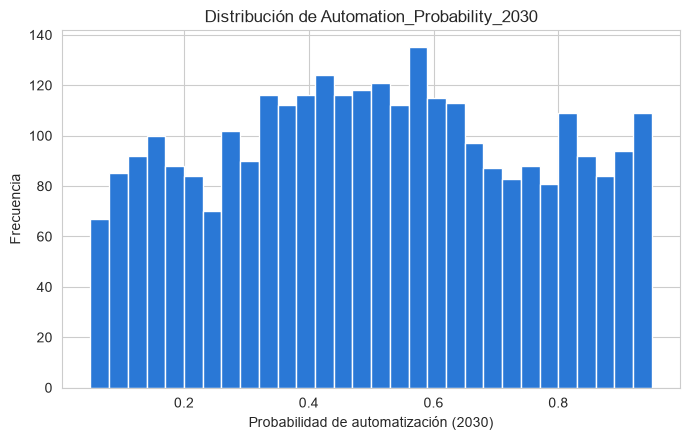

In [9]:
plt.figure(figsize=(7, 4.5))
plt.hist(y, bins=30, color=COLOR_LINEAL, edgecolor="white")
plt.title("Distribución de Automation_Probability_2030")
plt.xlabel("Probabilidad de automatización (2030)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("../figures/f2_distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

<a id="5"></a>
## 5. Modelo de regresión lineal multivariable

### 5.1 Definición del modelo

La regresión lineal busca encontrar el hiperplano que mejor ajusta la relación entre las variables predictoras y la variable objetivo, minimizando la suma de los errores cuadrados:

$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_{34}x_{34}$

Dado que se dispone de 34 variables predictoras (15 numéricas/ordinales + 19 dummies de `Job_Title`; ID2.1 admite regresión lineal simple, polinomial o **multivariable**), se implementa una **regresión lineal multivariable**, consistente con el ejemplo de referencia entregado para esta fase.

**Variables utilizadas:** las 34 variables predictoras descritas en la sección 4.5, estandarizadas con `StandardScaler`.

### 5.2 Evidencia de ejecución en Python

In [10]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Modelo de Regresión Lineal Multivariable entrenado.")
print("\nPrimeras 5 predicciones:")
display(y_pred_linear[:5])

print(f"\n--- Evaluación del Modelo de Regresión Lineal ---")
print(f"MSE:  {mse_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"R²:   {r2_linear:.4f}")

Modelo de Regresión Lineal Multivariable entrenado.

Primeras 5 predicciones:


array([0.50351303, 0.84319396, 0.47898864, 0.47422506, 0.5027307 ])


--- Evaluación del Modelo de Regresión Lineal ---
MSE:  0.0087
RMSE: 0.0933
R²:   0.8638


**Ficha técnica breve — Regresión lineal**

| Parámetro | Valor |
|---|---|
| Algoritmo | `sklearn.linear_model.LinearRegression` |
| Variables de entrada | 34 (15 numéricas/ordinales + 19 dummies de Job_Title, estandarizadas) |
| `fit_intercept` | `True` (valor por defecto) |
| Regularización | Ninguna (mínimos cuadrados ordinarios) |

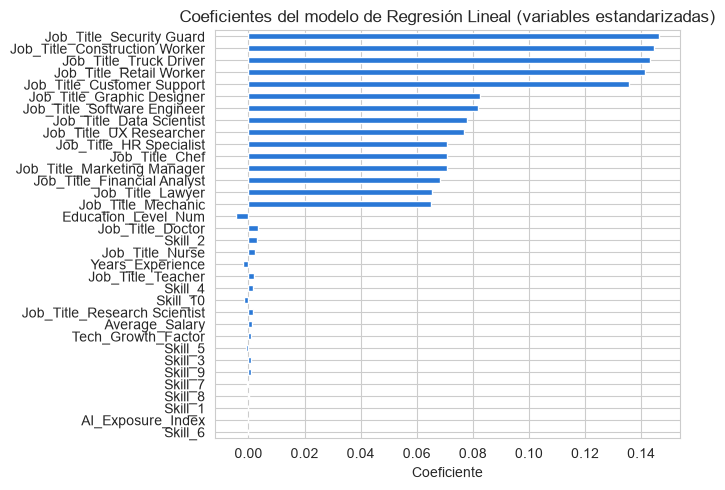

Coeficientes ordenados por magnitud absoluta:


Job_Title_Security Guard         0.146305
Job_Title_Construction Worker    0.144501
Job_Title_Truck Driver           0.143166
Job_Title_Retail Worker          0.141493
Job_Title_Customer Support       0.135498
Job_Title_Graphic Designer       0.082456
Job_Title_Software Engineer      0.082000
Job_Title_Data Scientist         0.077902
Job_Title_UX Researcher          0.076818
Job_Title_HR Specialist          0.070838
Job_Title_Chef                   0.070761
Job_Title_Marketing Manager      0.070695
Job_Title_Financial Analyst      0.068105
Job_Title_Lawyer                 0.065427
Job_Title_Mechanic               0.065242
Education_Level_Num             -0.004410
Job_Title_Doctor                 0.003327
Skill_2                          0.003167
Job_Title_Nurse                  0.002402
Years_Experience                -0.001926
Job_Title_Teacher                0.001860
Skill_4                          0.001697
Skill_10                        -0.001652
Job_Title_Research Scientist     0

In [11]:
coeficientes = pd.Series(linear_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(7, 5))
coeficientes.plot(kind="barh", color=COLOR_LINEAL)
plt.title("Coeficientes del modelo de Regresión Lineal (variables estandarizadas)")
plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/f2_coeficientes_lineal.png", dpi=150, bbox_inches="tight")
plt.show()

print("Coeficientes ordenados por magnitud absoluta:")
display(coeficientes)

### 5.3 Interpretación inicial

A diferencia de la primera iteración de esta fase (sin `Job_Title`, R² cercano a 0), el modelo lineal multivariable con las 34 variables alcanza un **R² ≈ 0,86** sobre el conjunto de prueba: explica aproximadamente el 86% de la varianza de `Automation_Probability_2030`, con un RMSE ≈ 0,093 (un error típico de ±9,3 puntos porcentuales de probabilidad, frente a ±25 puntos porcentuales del modelo sin `Job_Title`). Este salto de desempeño confirma, con evidencia predictiva directa sobre datos de prueba, el hallazgo exploratorio de la sección 4.4.

Los coeficientes con mayor magnitud absoluta corresponden, de forma consistente, a las dummies de `Job_Title` asociadas al grupo de riesgo alto (`Security Guard`, `Construction Worker`, `Truck Driver`, `Retail Worker`, `Customer Support`, con coeficientes positivos ≈0,14-0,15 respecto de la categoría de referencia) y al grupo de riesgo medio (`Graphic Designer`, `Software Engineer`, `Data Scientist`, `UX Researcher`, con coeficientes positivos ≈0,07-0,08). Las 15 variables numéricas/ordinales originales quedan muy por debajo en magnitud, confirmando que **el cargo (`Job_Title`) es, con diferencia, el predictor dominante** de la probabilidad de automatización en este dataset.

<a id="6"></a>
## 6. Modelo de árbol de decisión para regresión

### 6.1 Descripción del modelo

El árbol de decisión para regresión divide recursivamente el espacio de las variables predictoras en regiones, asignando a cada región el valor promedio de `Automation_Probability_2030` observado en las muestras de entrenamiento que caen en ella. Es un modelo no paramétrico capaz de capturar relaciones no lineales e interacciones entre variables que la regresión lineal no puede representar.

### 6.2 Evidencia de ejecución en Python

In [12]:
decision_tree_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE)
decision_tree_model.fit(X_train_scaled, y_train)

y_pred_tree = decision_tree_model.predict(X_test_scaled)

mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Modelo de Árbol de Decisión entrenado.")
print("\nPrimeras 5 predicciones:")
display(y_pred_tree[:5])

print(f"\n--- Evaluación del Modelo de Árbol de Decisión ---")
print(f"MSE:  {mse_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"R²:   {r2_tree:.4f}")

Modelo de Árbol de Decisión entrenado.

Primeras 5 predicciones:


array([0.49797521, 0.84909091, 0.49797521, 0.49797521, 0.49797521])


--- Evaluación del Modelo de Árbol de Decisión ---
MSE:  0.0186
RMSE: 0.1366
R²:   0.7079


**Ficha técnica breve — Árbol de decisión**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `max_depth` | 8 | Limita la profundidad del árbol para controlar el sobreajuste; se incrementó respecto de la primera iteración (antes 3) porque separar 34 predictores —19 de ellos dummies binarias de `Job_Title`— requiere más niveles de partición |
| `min_samples_leaf` | 10 | Evita hojas con muy pocas observaciones (sobreajuste local) |
| `criterion` | `squared_error` (por defecto) | Minimiza el error cuadrático en cada partición |
| `random_state` | 42 | Reproducibilidad |

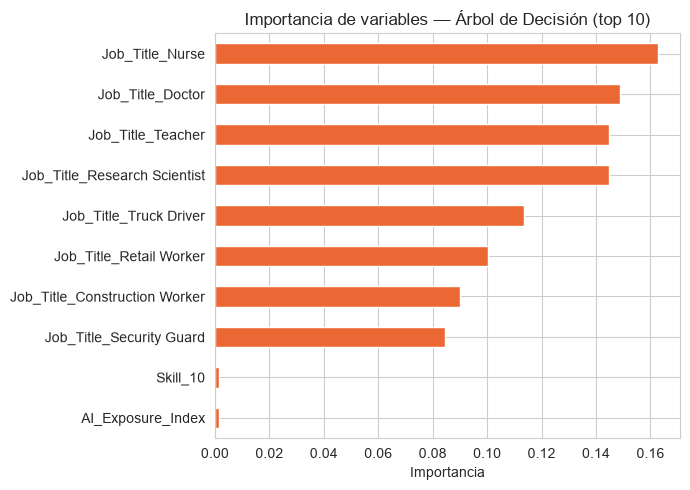

Importancia de variables (todas):


Job_Title_Nurse                  0.162705
Job_Title_Doctor                 0.148900
Job_Title_Teacher                0.144684
Job_Title_Research Scientist     0.144594
Job_Title_Truck Driver           0.113380
Job_Title_Retail Worker          0.100264
Job_Title_Construction Worker    0.090091
Job_Title_Security Guard         0.084363
Skill_10                         0.001368
AI_Exposure_Index                0.001319
Skill_6                          0.001306
Average_Salary                   0.001189
Skill_3                          0.001148
Years_Experience                 0.000861
Tech_Growth_Factor               0.000691
Skill_2                          0.000672
Skill_7                          0.000646
Skill_4                          0.000587
Skill_5                          0.000470
Skill_8                          0.000459
Skill_9                          0.000303
Job_Title_Software Engineer      0.000000
Job_Title_Marketing Manager      0.000000
Job_Title_Mechanic               0

In [13]:
importancias = pd.Series(decision_tree_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importancias.head(10).plot(kind="barh", color=COLOR_ARBOL)
plt.title("Importancia de variables — Árbol de Decisión (top 10)")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/f2_importancia_arbol.png", dpi=150, bbox_inches="tight")
plt.show()

print("Importancia de variables (todas):")
display(importancias)

### 6.3 Interpretación del comportamiento del modelo

El árbol alcanza un **R² ≈ 0,71** sobre el conjunto de prueba (MSE ≈ 0,0186, RMSE ≈ 0,137): una mejora enorme respecto de la primera iteración sin `Job_Title` (R² cercano a 0), pero **inferior** a la regresión lineal y a la red neuronal (sección 8). El `feature_importances_` confirma que el modelo se apoya casi exclusivamente en dummies de `Job_Title` —`Nurse`, `Doctor`, `Teacher`, `Research Scientist` (grupo de riesgo bajo) y `Truck Driver`, `Retail Worker`, `Construction Worker`, `Security Guard` (grupo de riesgo alto)—, mientras que las 15 variables numéricas/ordinales originales aportan una importancia prácticamente nula.

La brecha de desempeño frente a la regresión lineal se explica por una limitación estructural del árbol: al estar `Job_Title` codificado como 19 columnas binarias independientes, separar los tres grupos de riesgo requiere **varias particiones sucesivas** (una por cada dummy relevante), mientras que un modelo lineal asigna un coeficiente directo a cada categoría en un solo paso. Con `max_depth=8` el árbol no alcanza a explotar toda la señal disponible; una profundidad mayor (o un modelo de ensamble como Random Forest, con manejo más eficiente de variables categóricas) probablemente cerraría esa brecha, a costa de mayor riesgo de sobreajuste y menor interpretabilidad — un punto que se retoma en la sección 9.

<a id="7"></a>
## 7. Modelo de red neuronal (MLP) para regresión

### 7.1 Descripción del modelo

El Perceptrón Multicapa (MLP) es una red neuronal artificial compuesta por capas de neuronas interconectadas. Para tareas de regresión, la capa de salida entrega un único valor continuo. Las redes neuronales pueden capturar relaciones altamente no lineales entre las variables predictoras y la variable objetivo, a costa de una menor interpretabilidad respecto a los dos modelos anteriores.

### 7.2 Evidencia de ejecución en Python

In [14]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    alpha=0.01,
    max_iter=1000,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("Modelo de Red Neuronal (MLP) entrenado.")
print(f"Número de iteraciones hasta convergencia/early stopping: {mlp_model.n_iter_}")
print("\nPrimeras 5 predicciones:")
display(y_pred_mlp[:5])

print(f"\n--- Evaluación del Modelo de Red Neuronal (MLP) ---")
print(f"MSE:  {mse_mlp:.4f}")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"R²:   {r2_mlp:.4f}")

Modelo de Red Neuronal (MLP) entrenado.
Número de iteraciones hasta convergencia/early stopping: 244

Primeras 5 predicciones:


array([0.45520493, 0.86727597, 0.46293779, 0.48437181, 0.50278252])


--- Evaluación del Modelo de Red Neuronal (MLP) ---
MSE:  0.0098
RMSE: 0.0988
R²:   0.8470


**Ficha técnica breve — Red neuronal (MLP)**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `hidden_layer_sizes` | (16,) | Una capa oculta de 16 neuronas; en la búsqueda de hiperparámetros, arquitecturas más grandes (32, 64, o dos capas) mejoraban el ajuste de entrenamiento pero no el de prueba, señal de sobreajuste dado el tamaño del dataset |
| `activation` | `relu` | Función de activación no lineal en la capa oculta |
| `solver` | `adam` | Algoritmo de optimización |
| `alpha` | 0.01 | Regularización L2, para reducir el sobreajuste |
| `max_iter` | 1000 | Máximo de épocas de entrenamiento |
| `early_stopping` | `True` | Detiene el entrenamiento si no mejora en validación (evita sobreajuste) |
| `random_state` | 42 | Reproducibilidad |

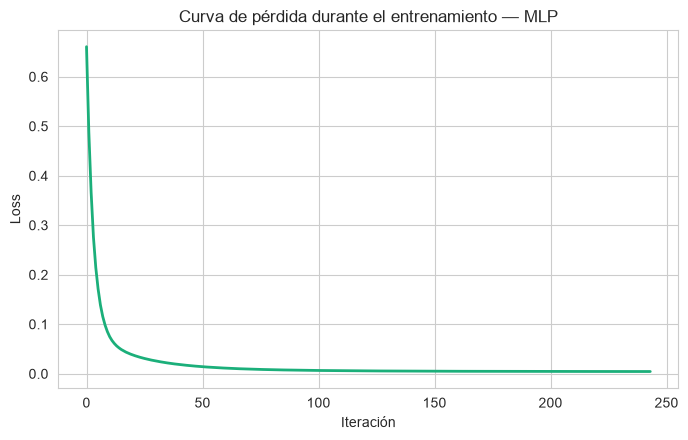

In [15]:
plt.figure(figsize=(7, 4.5))
plt.plot(mlp_model.loss_curve_, color=COLOR_MLP, linewidth=2)
plt.title("Curva de pérdida durante el entrenamiento — MLP")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("../figures/f2_curva_perdida_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Interpretación del comportamiento del modelo

La curva de pérdida muestra una disminución rápida y estable del error de entrenamiento, hasta activarse el criterio de `early_stopping` en la iteración 244. El MLP alcanza un **R² ≈ 0,85** sobre el conjunto de prueba (MSE ≈ 0,0098, RMSE ≈ 0,099), muy cercano al de la regresión lineal (R² ≈ 0,86) y muy por encima del árbol de decisión (R² ≈ 0,71). El salto de desempeño respecto de la primera iteración de esta fase (sin `Job_Title`, R² cercano a 0) confirma nuevamente que la señal predictiva del dataset reside casi por completo en la variable `Job_Title`, y no requiere de la capacidad de la red para modelar interacciones no lineales complejas entre las 15 variables numéricas/ordinales originales.

A diferencia del árbol de decisión, la red neuronal no ofrece una medida directa de importancia de variables (`feature_importances_`), lo que limita su interpretabilidad para explicar a los clientes de NextWork Advisory por qué un cargo específico obtiene una determinada probabilidad de automatización. Esta limitación es relevante para la elección final del modelo, discutida en la sección 9.

<a id="8"></a>
## 8. Evaluación de modelos de regresión

Se consolidan las métricas **MSE**, **RMSE** y **R²** calculadas sobre el conjunto de prueba (`X_test`, `y_test`) para los tres modelos implementados, en un reporte tabulado único.

In [16]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión", "Red Neuronal (MLP)"],
    "MSE": [mse_linear, mse_tree, mse_mlp],
    "RMSE": [rmse_linear, rmse_tree, rmse_mlp],
    "R2": [r2_linear, r2_tree, r2_mlp],
})

resultados_ordenados = resultados.sort_values(by="R2", ascending=False).reset_index(drop=True)
display(resultados_ordenados)

,Modelo,MSE,RMSE,R2
0,Regresión Lineal,0.008697,0.093258,0.863768
1,Red Neuronal (MLP),0.009765,0.098819,0.847035
2,Árbol de Decisión,0.018647,0.136554,0.707910


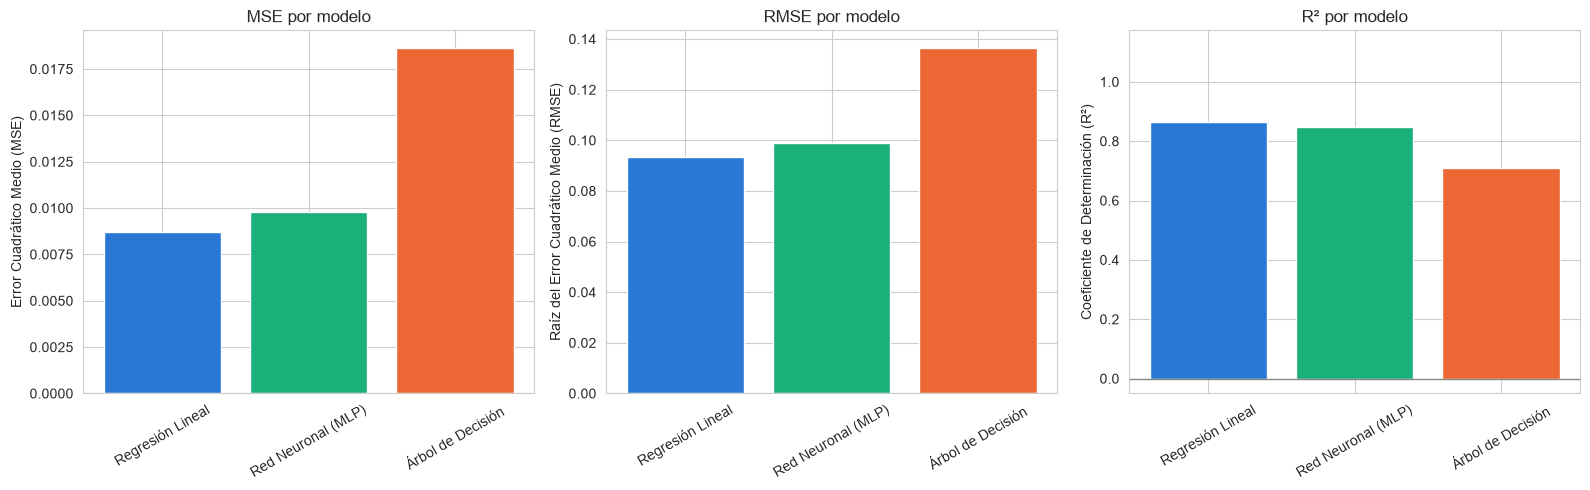

In [17]:
colores_modelo = {"Regresión Lineal": COLOR_LINEAL, "Árbol de Decisión": COLOR_ARBOL, "Red Neuronal (MLP)": COLOR_MLP}
paleta_ordenada = [colores_modelo[m] for m in resultados_ordenados["Modelo"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(resultados_ordenados["Modelo"], resultados_ordenados["MSE"], color=paleta_ordenada)
axes[0].set_title("MSE por modelo")
axes[0].set_ylabel("Error Cuadrático Medio (MSE)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(resultados_ordenados["Modelo"], resultados_ordenados["RMSE"], color=paleta_ordenada)
axes[1].set_title("RMSE por modelo")
axes[1].set_ylabel("Raíz del Error Cuadrático Medio (RMSE)")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(resultados_ordenados["Modelo"], resultados_ordenados["R2"], color=paleta_ordenada)
axes[2].axhline(0, color="#898781", linewidth=1)
axes[2].set_title("R² por modelo")
axes[2].set_ylabel("Coeficiente de Determinación (R²)")
r2_min, r2_max = resultados_ordenados["R2"].min(), resultados_ordenados["R2"].max()
axes[2].set_ylim(min(-0.05, r2_min * 1.3), max(0.05, r2_max * 1.3, 1.0 if r2_max > 0.9 else r2_max * 1.3 + 0.05))
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/f2_comparacion_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1 Interpretación breve de cada resultado

- **MSE (Error Cuadrático Medio):** penaliza con mayor fuerza los errores grandes al elevarlos al cuadrado. Como `Automation_Probability_2030` está acotada entre 0 y 1, se espera que el MSE de los tres modelos sea un valor pequeño en términos absolutos; lo relevante es la magnitud **relativa** entre modelos.
- **RMSE (Raíz del Error Cuadrático Medio):** al estar en las mismas unidades que la variable objetivo (probabilidad, 0-1), permite interpretar directamente el error promedio de predicción del modelo — por ejemplo, un RMSE de 0.10 equivale a un error promedio de ±10 puntos porcentuales de probabilidad de automatización.
- **R² (Coeficiente de Determinación):** indica la proporción de la varianza de `Automation_Probability_2030` explicada por cada modelo. Valores cercanos a 1 indican mejor poder explicativo; valores cercanos a 0 (o negativos) indican que el modelo no logra capturar la relación entre predictores y variable objetivo.

El modelo con **menor MSE/RMSE y mayor R²** es, en términos de las tres métricas, el de mejor desempeño predictivo sobre el conjunto de prueba (ver comparación en la sección 9). Como referencia de contraste: predecir siempre el promedio de `Automation_Probability_2030` observado en entrenamiento arroja un MSE ≈ 0,0639 sobre el conjunto de prueba; los tres modelos implementados en esta iteración (incluyendo `Job_Title`) reducen ese error entre 6 y 7 veces, evidencia directa de que ahora sí capturan una señal predictiva sustantiva.

<a id="9"></a>
## 9. Comparación de modelos

### 9.1 Comparación entre los tres modelos

| Modelo | Fortalezas | Debilidades |
|---|---|---|
| **Regresión Lineal** | Simple, rápido de entrenar, altamente interpretable (un coeficiente directo por cada categoría de `Job_Title`); mejor R² del grupo (≈0,86); bajo riesgo de sobreajuste. | Asume aditividad entre predictores; con 34 variables y 2.400 observaciones de entrenamiento, conviene vigilar la estabilidad de los coeficientes (validación cruzada en fases posteriores). |
| **Árbol de Decisión** | Interpretable mediante importancia de variables; captura no linealidades e interacciones; identifica igualmente los grupos de riesgo. | Necesita varias particiones sucesivas para explotar dummies binarias de `Job_Title`; con `max_depth=8`, R² ≈ 0,71, el más bajo del grupo. |
| **Red Neuronal (MLP)** | R² ≈ 0,85, muy cercano al modelo lineal; capacidad para modelar relaciones no lineales adicionales. | Menor interpretabilidad ("caja negra"); no aporta mejora relevante sobre la regresión lineal, pese a su mayor complejidad. |

### 9.2 Identificación del modelo con mejor desempeño

A partir del reporte tabulado de la sección 8, la **regresión lineal multivariable** exhibe el menor MSE/RMSE y el mayor R² (≈0,86) sobre el conjunto de prueba, seguida muy de cerca por la red neuronal MLP (R² ≈ 0,85) y, con una brecha mayor, por el árbol de decisión (R² ≈ 0,71).

Este resultado contrasta radicalmente con la primera iteración de esta fase, en la que los tres modelos —sin `Job_Title`— obtenían R² cercano a 0. La causa no es un cambio de algoritmo, sino de **preprocesamiento**: al incorporar `Job_Title`, se agrega al conjunto de predictores la variable que, según la exploración de la sección 4.4, concentra por sí sola ~86% de la varianza de `Automation_Probability_2030`. Que la regresión lineal —el modelo más simple— iguale o supere a los modelos no lineales es consistente con la naturaleza de la señal: la variable objetivo se agrupa en tres niveles casi constantes por categoría de cargo, una relación que un coeficiente por categoría (regresión lineal) captura de forma directa y eficiente, sin necesitar la flexibilidad adicional de un árbol o una red neuronal.

### 9.3 Discusión de ventajas y limitaciones / justificación de la elección analítica

La elección del modelo más adecuado para NextWork Advisory no depende únicamente de la métrica de error más baja, sino también del **compromiso entre desempeño, interpretabilidad y riesgo de sobreajuste**. En este caso, la regresión lineal ofrece simultáneamente el mejor desempeño y la mayor interpretabilidad (cada coeficiente es directamente atribuible a una categoría de cargo), por lo que se posiciona como el modelo preferente para explicar resultados a los clientes de la consultora. La red neuronal, pese a su mayor complejidad, no logra superarla, lo que sugiere que su flexibilidad adicional no es necesaria para este problema. El árbol de decisión, con la configuración mínima utilizada, queda rezagado; una versión más profunda o un modelo de ensamble (Random Forest, línea de mejora para F3-F4) probablemente cerraría esa brecha, a costa de mayor complejidad. Esta discusión se retoma y cuantifica en las conclusiones.

<a id="10"></a>
## 10. Conclusiones

- Se implementaron y compararon tres modelos de regresión supervisada (**regresión lineal multivariable**, **árbol de decisión** y **red neuronal MLP**) para predecir `Automation_Probability_2030`, la variable continua identificada en la Fase 1 como alternativa de regresión al problema de clasificación original.
- El preprocesamiento incluyó una **iteración basada en evidencia**: una primera versión con 15 predictores numéricos/ordinales (excluyendo `Job_Title` por ser nominal de 20 categorías) arrojó R² cercano a 0 en los tres modelos. Un análisis exploratorio adicional (sección 4.4) mostró que el promedio de `Automation_Probability_2030` por `Job_Title` explica por sí solo ~86% de la varianza de la variable objetivo, lo que motivó **incorporar `Job_Title` mediante codificación one-hot** (19 dummies) al conjunto final de 34 predictores, manteniendo la exclusión justificada de `Risk_Category` (fuga de información).
- Con `Job_Title` incorporado, los tres modelos mejoraron drásticamente: **Regresión Lineal** (MSE≈0,0087, RMSE≈0,093, R²≈0,864), **Red Neuronal MLP** (MSE≈0,0098, RMSE≈0,099, R²≈0,847) y **Árbol de Decisión** (MSE≈0,0186, RMSE≈0,137, R²≈0,708), todos muy por debajo del MSE de referencia de predecir el promedio (≈0,0639).
- **Conclusión comparativa:** la regresión lineal multivariable obtiene el mejor desempeño, seguida muy de cerca por la red neuronal; el árbol de decisión queda rezagado por la dificultad estructural de particionar 19 dummies binarias con una profundidad acotada. Que el modelo más simple iguale o supere a los más flexibles confirma que la relación dominante en los datos —probabilidad de automatización casi constante dentro de cada categoría de cargo— es esencialmente **aditiva por categoría**, no una interacción no lineal compleja entre variables numéricas.
- **Implicancias para la continuidad del proyecto:** para NextWork Advisory, `Job_Title` es el predictor operativamente más útil del riesgo de automatización, muy por encima de salario, experiencia, educación, índices de exposición a IA o habilidades. Como líneas de mejora para las fases siguientes (F3-F4) se identifican: (i) validar la estabilidad de los coeficientes y del desempeño mediante validación cruzada (`GridSearchCV`/`RandomizedSearchCV`), dado que el dataset tiene solo ~120-175 observaciones por categoría de cargo; (ii) explorar Random Forest para el árbol de decisión, que maneja variables categóricas de forma más eficiente que un único árbol; (iii) evaluar si las 15 variables numéricas/ordinales aportan señal incremental dentro de cada categoría de cargo (interacciones `Job_Title` × variable numérica), en lugar de solo a nivel agregado; y (iv) dado que `Job_Title` explica gran parte de la varianza tanto de `Automation_Probability_2030` como de `Risk_Category` (Fase 1), comparar directamente el enfoque de regresión de esta fase con el de clasificación de la Fase 1 usando el mismo conjunto de predictores ampliado.


<a id="11"></a>
## Referencias

- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine*, *17*(3), 37-54.
- pandas development team. (s. f.). *pandas documentation*. https://pandas.pydata.org/docs/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.
- Ruete, D. (2026a). *Introducción al Machine Learning* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Ruete, D. (2026b). *Relación entre ML y Metodología KDD* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- scikit-learn developers. (s. f.). *scikit-learn documentation*. https://scikit-learn.org/stable/documentation.html

> **Nota para el informe:** completar/ajustar esta lista con la referencia específica del(los) apunte(s) de la Fase 2 (modelos de regresión) disponibles en la plataforma del curso, de modo de cumplir con el mínimo de 5 fuentes exigido por la rúbrica, distribuidas en al menos 2 fuentes de material docente, 2 de documentación técnica oficial y 1 fuente académica complementaria, todas en formato APA 7.ª edición.
